In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
# Read data
df = pd.read_csv("winequality-white.csv", delimiter=';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Data pre-processing
HINT: Scale numerical values using *StandardScaler*

Explain what is changed.

In [4]:
# Data pre-processing: Write code
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
data_scaled = scaler.fit_transform(df)

# Convert scaled data back to DataFrame for readability
df_scaled = pd.DataFrame(data_scaled, columns=df.columns)

# Print first 5 rows
df_scaled.head()


# Print first 5 rows of the NumPy array
# print(data_scaled[:5])
df_scaled = pd.DataFrame(data_scaled, columns=df.columns) # Covert NumPy array to Dataframe
df_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.172097,-0.081770,0.213280,2.821349,-0.035355,0.569932,0.744565,2.331512,-1.246921,-0.349184,-1.393152,0.13787
1,-0.657501,0.215896,0.048001,-0.944765,0.147747,-1.253019,-0.149685,-0.009154,0.740029,0.001342,-0.824276,0.13787
2,1.475751,0.017452,0.543838,0.100282,0.193523,-0.312141,-0.973336,0.358665,0.475102,-0.436816,-0.336667,0.13787
3,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0.13787
4,0.409125,-0.478657,-0.117278,0.415768,0.559727,0.687541,1.121091,0.525855,0.011480,-0.787342,-0.499203,0.13787


### Apply K-Means and Hierarchical (agglomerative) Clustering
Note: Apply two approaches on both winequality-white.csv and winequality-red.csv

In [5]:
# Apply K-Means Clustering: Write code
# --- K-Means Clustering ---

# Step 1: Choose number of clusters
k = 3   # you can change this after checking elbow/silhouette

# Step 2: Initialize model
kmeans = KMeans(n_clusters=k, random_state=42)

# Step 3: Fit model on scaled data
kmeans.fit(data_scaled)

# Step 4: Get cluster labels
kmeans_labels = kmeans.labels_

# Step 5: Attach labels to dataframe (for analysis)
df_kmeans = df.copy()
df_kmeans['Cluster'] = kmeans_labels

# Quick check
df_kmeans.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,2
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,2
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,2


In [6]:
# Apply Hierarchical (agglomerative) Clustering: Write code
# --- Hierarchical Clustering ---

# Step 1: Create model
agglo = AgglomerativeClustering(n_clusters=3)

# Step 2: Fit and predict
agglo_labels = agglo.fit_predict(data_scaled)

# Step 3: Attach labels to dataframe
df_agglo = df.copy()
df_agglo['Cluster'] = agglo_labels

# Quick check
df_agglo.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0


### Visualizing Clusters: KMeans

Principal Component Analysis (PCA) is a powerful dimensionality reduction technique used in machine learning and data analysis to simplify complex datasets while preserving as much important information as possible. It works by transforming the original high-dimensional data into a new coordinate system where the axes (called principal components) capture the directions of maximum variance in the data. The first principal component accounts for the most variance, followed by the second, and so on. When visualizing high-dimensional data, PCA is particularly useful as it allows us to project the data into just two components (PCA1 and PCA2), enabling a meaningful 2D representation of the dataset. This transformation helps in clustering, classification, and pattern recognition by revealing inherent structures within the data. In clustering tasks like K-Means and Hierarchical Clustering, PCA aids in visualization by reducing noise and allowing us to plot the clusters effectively, making it easier to interpret patterns and relationships within the dataset.

HINT: Use Principal Component Analysis (PCA) to reduce high-dimensional data to 2 components. Use *seaborn.scatterplot*

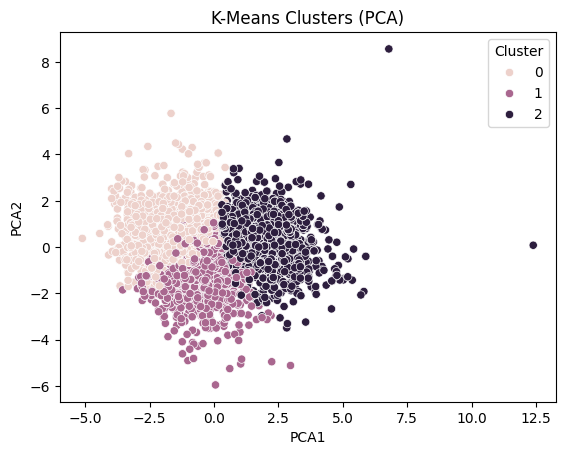

In [7]:
# Visualizing Clusters using PCA: Write code
# reduce data to 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)

# make a small dataframe for plotting
df_pca = pd.DataFrame(pca_data, columns=["PCA1", "PCA2"])

# add cluster labels
df_pca["Cluster"] = kmeans_labels

# plot
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df_pca)

plt.title("K-Means Clusters (PCA)")
plt.show()



### Optimal _k_
Find the optimal number of clusters (k) using the Elbow Method.

Inertia, also known as the Within-Cluster Sum of Squares (WCSS), is a key metric used in K-Means clustering to measure how well data points are assigned to their respective clusters. It is calculated as the sum of the squared distances between each data point and the centroid of its assigned cluster.  A lower inertia value indicates that data points are closely packed around their centroids, signifying well-formed clusters.

To determine the optimal number of clusters (k), the Elbow Method is commonly used, which involves plotting inertia values for different values of k and identifying the "elbow point" - the location where the rate of decrease sharply slows down, suggesting the best balance between compact clusters and overfitting. In Python, this can be easily computed using _kmeans.inertia__ from the _sklearn.cluster.KMeans_ module. By iterating over a range of k values and plotting their corresponding inertia scores, we can visualize the optimal number of clusters. The resulting Elbow Plot helps guide the selection of k by pinpointing where adding more clusters no longer significantly reduces inertia, ensuring a well-optimized clustering solution.

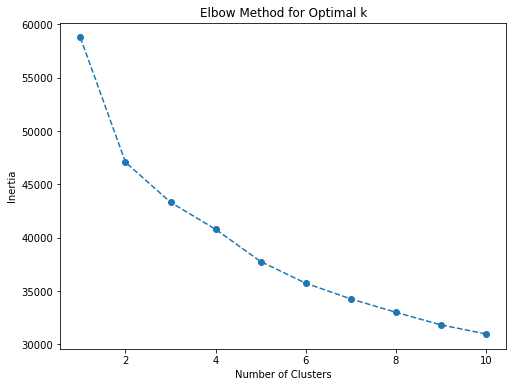

In [ ]:
# Finding optimal k using Elbow Method: Write code




### Visualizing Clusters: Agglomerative
 - Visualize using scatter plot - similar to KMeans
 - Generate a dendrogram to visualize hierarchical clustering.
 - Optimal k. Note: The **Silhouette Score** measures the cohesion and separation of clusters, helping determine the best k. A higher score indicates better clustering.

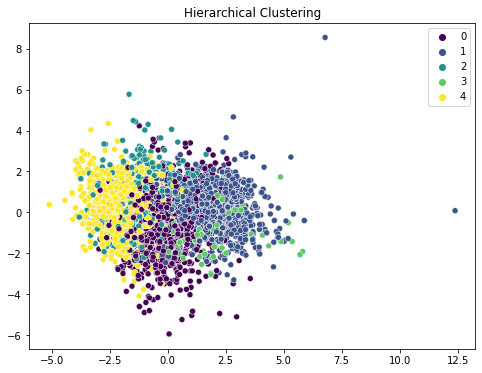

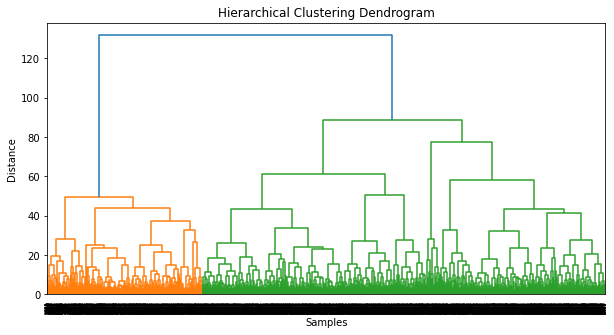

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,KMeans_Cluster,Hierarchical_Cluster
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,1,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,3,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1,0


In [ ]:
# Hierarchical Visualization: Write code



# Dendrogram for Hierarchical Clustering: Write code



# Display the first few rows of the dataset with cluster labels
df.head()

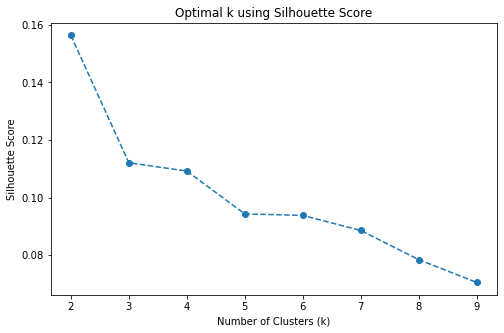

In [ ]:
# Try different values of k and compute silhouette scores
silhouette_scores = []
K = range(2, 10)  # Trying values of k from 2 to 10
# Write code



# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k using Silhouette Score')
plt.show()